### Implementação em python das soluções de alguns dos problemas de programação linear

INFO:__main__:LaTeX text rendering enabled.


x_2 = 2.333333333333333, x_1 = 1
z(x_1, x_2)=4.333333333333333


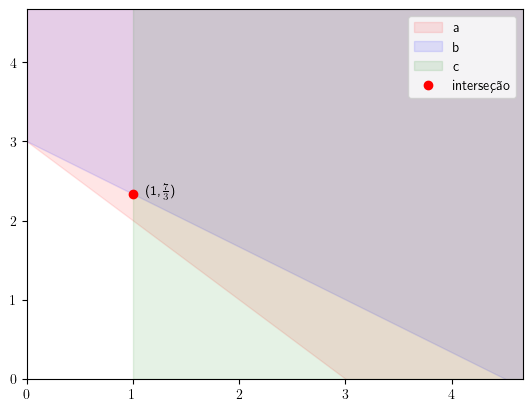

In [244]:
#!/usr/bin/env python3
"""
3D trajectory integrator + plotting.
"""
from __future__ import annotations

import logging
from typing import Callable, Optional, Tuple

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# --- Logging / Matplotlib setup ---
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# Try to enable LaTeX rendering, but don't crash if unavailable.
try:
    mpl.rcParams["text.usetex"] = True
    mpl.rcParams["pgf.texsystem"] = "pdflatex"
    logger.info("LaTeX text rendering enabled.")
except Exception:
    mpl.rcParams["text.usetex"] = False
    logger.info("LaTeX not available; using Matplotlib text rendering.")

plt.close("all")

a = lambda x_1: 3 - x_1
b = lambda x_1: (1/3) * (9 - 2 * x_1)
c = lambda t: (np.ones(t.size), t)
t = np.linspace(0, 10, 50)
ax = plt.subplot()
ax.axes.set_xlim((0, 4 + 2/3))
ax.axes.set_ylim((0, 4 + 2/3))
ax.fill_between(t, a(t), 10, label='a', alpha=0.1, color='r')
ax.fill_between(t, b(t), 10, label='b', alpha=0.1, color='b')
cc = c(t)
ax.fill_betweenx(cc[1], 1, 10, label='c', alpha=0.1, color='g')
#ax.fill_between(cc[0], cc[1], label='c')
x_1 = 1
x_2 = b(x_1)
ax.plot(x_1, x_2, 'ro', label='interseção')
ax.annotate(f'({x_1},$\\frac{{7}}{{3}}$)', (x_1, x_2), xytext=(1.125,2.333))
ax.legend()
print(f'x_2 = {b(1)}, x_1 = 1')
z = lambda x_1, x_2: 2*x_1 + x_2
print(f'{z(x_1, x_2)=}')
plt.savefig('prob1.pgf')
plt.show();


#### Solver Excel Tabelas

In [245]:
import pandas as pd

variaveis = pd.DataFrame({"Variáveis do Sistema": {
    "x_1": float('nan'), "x_2": float('nan')
}},)
variaveis

,Variáveis do Sistema
x_1,NaN
x_2,NaN


In [246]:
print(variaveis.to_latex())

\begin{tabular}{lr}
\toprule
 & Variáveis do Sistema \\
\midrule
x_1 & NaN \\
x_2 & NaN \\
\bottomrule
\end{tabular}



In [247]:
import pandas as pd

r'''restricoes = pd.DataFrame({
    "Restrições": {
        "Nome": ["R_1", "R_2", "R_3"],
        "Fórmula": ["x_1 + x_3", "2x_1 + 3x_2", "x_1"],
        "Tipo": [r"\ge", r'\ge', r"\ge"],
        "Limite": [3, 9, 1]
    }
})'''
restricoes = pd.DataFrame({
    "Restrições":["$R_1$", "$R_2$", "$R_3$"],
    "Fórmula": ["$x_1 + x_3$", "$2x_1 + 3x_2$", "$x_1$"],
    "Tipo": [r"$\ge$", r"$\ge$", r"$\ge$"],
    "Limite": [3, 9, 1]
})
restricoes

,Restrições,Fórmula,Tipo,Limite
0,$R_1$,$x_1 + x_3$,$\ge$,3
1,$R_2$,$2x_1 + 3x_2$,$\ge$,9
2,$R_3$,$x_1$,$\ge$,1


In [248]:
print(restricoes.to_latex(index=False))

\begin{tabular}{lllr}
\toprule
Restrições & Fórmula & Tipo & Limite \\
\midrule
$R_1$ & $x_1 + x_3$ & $\ge$ & 3 \\
$R_2$ & $2x_1 + 3x_2$ & $\ge$ & 9 \\
$R_3$ & $x_1$ & $\ge$ & 1 \\
\bottomrule
\end{tabular}



### Entrivistas

In [249]:
import pandas as pd

custos = pd.DataFrame({
    'Tipos de Família': ['Com criança', 'Sem criança'],
    'Custo Dia': [r'R\$ 10,00', r'R\$ 8,00'],
    'Custo Noite': [r'R\$ 12,00', r'R\$ 10,00']
})
custos

,Tipos de Família,Custo Dia,Custo Noite
0,Com criança,"R\$ 10,00","R\$ 12,00"
1,Sem criança,"R\$ 8,00","R\$ 10,00"


In [250]:
print(custos.to_latex(index=False))

\begin{tabular}{lll}
\toprule
Tipos de Família & Custo Dia & Custo Noite \\
\midrule
Com criança & R\$ 10,00 & R\$ 12,00 \\
Sem criança & R\$ 8,00 & R\$ 10,00 \\
\bottomrule
\end{tabular}



In [251]:
import pandas as pd

restricoes1 = pd.DataFrame({
    'Nome da restrição': ['$R_1$', "$R_2$", "$R_3$", "$R_4$"],
    "Fórmula": ["$x_1 + x_2$", "$x_3 + x_4$", "$-x_1 -x_2 + x_3 + x_4$", "$x_1 + x_2 + x_3 + x_4$"],
    "Tipo": [r'$\ge$', r'$\ge$', r'$\ge$', r'$\ge$'],
    "Limite": [400, 200, 0, 1000]
})
restricoes1

,Nome da restrição,Fórmula,Tipo,Limite
0,$R_1$,$x_1 + x_2$,$\ge$,400
1,$R_2$,$x_3 + x_4$,$\ge$,200
2,$R_3$,$-x_1 -x_2 + x_3 + x_4$,$\ge$,0
3,$R_4$,$x_1 + x_2 + x_3 + x_4$,$\ge$,1000


In [252]:
print(restricoes1.to_latex(index=False))

\begin{tabular}{lllr}
\toprule
Nome da restrição & Fórmula & Tipo & Limite \\
\midrule
$R_1$ & $x_1 + x_2$ & $\ge$ & 400 \\
$R_2$ & $x_3 + x_4$ & $\ge$ & 200 \\
$R_3$ & $-x_1 -x_2 + x_3 + x_4$ & $\ge$ & 0 \\
$R_4$ & $x_1 + x_2 + x_3 + x_4$ & $\ge$ & 1000 \\
\bottomrule
\end{tabular}



In [253]:
import pandas as pd

coefs = pd.DataFrame({
    "Básicas": ['$-W$', '$a_1$', '$a_2$', '$a_3$','$a_4$'],
    '$x_1$': [-1, 1, 0, -1, 1],
    '$x_2$': [-1, 1, 0, -1, 1],
    '$x_3$': [-3, 0, 1, 1, 1],
    '$x_4$': [-3, 0, 1, 1, 1],
    '$s_1$': [1, -1, 0, 0, 0],
    '$s_2$': [1, 0, -1, 0, 0],
    '$s_3$': [1, 0, 0, -1, 0],
    '$s_4$': [1, 0, 0, 0, -1],
    '$a_1$': [0, 1, 0, 0, 0],
    '$a_2$': [0, 0, 1, 0, 0],
    '$a_3$': [0, 0, 0, 1, 0],
    '$a_4$': [0, 0, 0, 0, 1],
    'Constantes': [-1600, 400, 200, 0, 1000],
})

coefs

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,-1,-1,-3,-3,1,1,1,1,0,0,0,0,-1600
1,$a_1$,1,1,0,0,-1,0,0,0,1,0,0,0,400
2,$a_2$,0,0,1,1,0,-1,0,0,0,1,0,0,200
3,$a_3$,-1,-1,1,1,0,0,-1,0,0,0,1,0,0
4,$a_4$,1,1,1,1,0,0,0,-1,0,0,0,1,1000


In [254]:
print(coefs.to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & -1 & -1 & -3 & -3 & 1 & 1 & 1 & 1 & 0 & 0 & 0 & 0 & -1600 \\
$a_1$ & 1 & 1 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 400 \\
$a_2$ & 0 & 0 & 1 & 1 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 200 \\
$a_3$ & -1 & -1 & 1 & 1 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 \\
$a_4$ & 1 & 1 & 1 & 1 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 1000 \\
\bottomrule
\end{tabular}



In [255]:
coefs.iloc[:, :]

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,-1,-1,-3,-3,1,1,1,1,0,0,0,0,-1600
1,$a_1$,1,1,0,0,-1,0,0,0,1,0,0,0,400
2,$a_2$,0,0,1,1,0,-1,0,0,0,1,0,0,200
3,$a_3$,-1,-1,1,1,0,0,-1,0,0,0,1,0,0
4,$a_4$,1,1,1,1,0,0,0,-1,0,0,0,1,1000


In [256]:
#coefs.iloc[0, 1:] - coefs.iloc[0, 3] * coefs.iloc[2, 1:]

In [257]:
#coefs.iloc[2, :]

In [258]:
coefs1 = coefs.copy()
# Coluna 1 é coluna pivô
# Linha 3 é linha pivô
coefs1.iloc[3, 1:] /= coefs1.iloc[3, 1]
coefs1.iloc[0, 1:] -= coefs1.iloc[0, 1] * coefs1.iloc[3, 1:]
coefs1.iloc[1, 1:] -= coefs1.iloc[1, 1] * coefs1.iloc[3, 1:]
coefs1.iloc[2, 1:] -= coefs1.iloc[2, 1] * coefs1.iloc[3, 1:]
#coefs1.iloc[3, 1:] -= coefs1.iloc[3, 1] * coefs1.iloc[3, 1:] # linha pivô não é alterada aqui
coefs1.iloc[4, 1:] -= coefs1.iloc[4, 1] * coefs1.iloc[3, 1:]
coefs1.iloc[3, 0] = '$x_1$'
coefs1

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,0,0,-4,-4,1,1,2,1,0,0,-1,0,-1600
1,$a_1$,0,0,1,1,-1,0,-1,0,1,0,1,0,400
2,$a_2$,0,0,1,1,0,-1,0,0,0,1,0,0,200
3,$x_1$,1,1,-1,-1,0,0,1,0,0,0,-1,0,0
4,$a_4$,0,0,2,2,0,0,-1,-1,0,0,1,1,1000


In [259]:
print(coefs1.to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & 0 & 0 & -4 & -4 & 1 & 1 & 2 & 1 & 0 & 0 & -1 & 0 & -1600 \\
$a_1$ & 0 & 0 & 1 & 1 & -1 & 0 & -1 & 0 & 1 & 0 & 1 & 0 & 400 \\
$a_2$ & 0 & 0 & 1 & 1 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 200 \\
$x_1$ & 1 & 1 & -1 & -1 & 0 & 0 & 1 & 0 & 0 & 0 & -1 & 0 & 0 \\
$a_4$ & 0 & 0 & 2 & 2 & 0 & 0 & -1 & -1 & 0 & 0 & 1 & 1 & 1000 \\
\bottomrule
\end{tabular}



In [260]:
# Coluna 3 é coluna pivô
# Linha 3 é linha pivô

coefs2 = coefs1.copy()
coefs2.iloc[3, 1:] /= coefs2.iloc[3, 3]
coefs2.iloc[0, 1:] -= coefs2.iloc[0, 3] * coefs2.iloc[3, 1:]
coefs2.iloc[1, 1:] -= coefs2.iloc[1, 3] * coefs2.iloc[3, 1:]
coefs2.iloc[2, 1:] -= coefs2.iloc[2, 3] * coefs2.iloc[3, 1:]
# coefs2.iloc[3, 1:] -= coefs2.iloc[3, 3] * coefs2.iloc[3, 1:]
coefs2.iloc[4, 1:] -= coefs2.iloc[4, 3] * coefs2.iloc[3, 1:]
coefs2.iloc[3, 0] = '$x_3$'
coefs2

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,-4,-4,0,0,1,1,-2,1,0,0,3,0,-1600
1,$a_1$,1,1,0,0,-1,0,0,0,1,0,0,0,400
2,$a_2$,1,1,0,0,0,-1,1,0,0,1,-1,0,200
3,$x_3$,-1,-1,1,1,0,0,-1,0,0,0,1,0,0
4,$a_4$,2,2,0,0,0,0,1,-1,0,0,-1,1,1000


In [261]:
print(coefs2.to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & -4 & -4 & 0 & 0 & 1 & 1 & -2 & 1 & 0 & 0 & 3 & 0 & -1600 \\
$a_1$ & 1 & 1 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 400 \\
$a_2$ & 1 & 1 & 0 & 0 & 0 & -1 & 1 & 0 & 0 & 1 & -1 & 0 & 200 \\
$x_3$ & -1 & -1 & 1 & 1 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 \\
$a_4$ & 2 & 2 & 0 & 0 & 0 & 0 & 1 & -1 & 0 & 0 & -1 & 1 & 1000 \\
\bottomrule
\end{tabular}



In [262]:
# Coluna 1 é coluna pivô
# Linha 2 é linha pivô

coefs3 = coefs2.copy()
coefs3.iloc[2, 1:] /= coefs3.iloc[2, 1]
coefs3.iloc[0, 1:] -= coefs3.iloc[0, 1] * coefs3.iloc[2, 1:]
coefs3.iloc[1, 1:] -= coefs3.iloc[1, 1] * coefs3.iloc[2, 1:]
#coefs3.iloc[2, 1:] -= coefs3.iloc[2, 1] * coefs3.iloc[2, 1:]
coefs3.iloc[3, 1:] -= coefs3.iloc[3, 1] * coefs3.iloc[2, 1:]
coefs3.iloc[4, 1:] -= coefs3.iloc[4, 1] * coefs3.iloc[2, 1:]
coefs3.iloc[2, 0] = '$x_1$'
coefs3

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,0,0,0,0,1,-3,2,1,0,4,-1,0,-800
1,$a_1$,0,0,0,0,-1,1,-1,0,1,-1,1,0,200
2,$x_1$,1,1,0,0,0,-1,1,0,0,1,-1,0,200
3,$x_3$,0,0,1,1,0,-1,0,0,0,1,0,0,200
4,$a_4$,0,0,0,0,0,2,-1,-1,0,-2,1,1,600


In [263]:
print(coefs3.to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & 0 & 0 & 0 & 0 & 1 & -3 & 2 & 1 & 0 & 4 & -1 & 0 & -800 \\
$a_1$ & 0 & 0 & 0 & 0 & -1 & 1 & -1 & 0 & 1 & -1 & 1 & 0 & 200 \\
$x_1$ & 1 & 1 & 0 & 0 & 0 & -1 & 1 & 0 & 0 & 1 & -1 & 0 & 200 \\
$x_3$ & 0 & 0 & 1 & 1 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 200 \\
$a_4$ & 0 & 0 & 0 & 0 & 0 & 2 & -1 & -1 & 0 & -2 & 1 & 1 & 600 \\
\bottomrule
\end{tabular}



In [264]:
# Coluna 6 é coluna pivô
# Linha 1 é linha pivô

coefs4 = coefs3.copy()
coefs4.iloc[1, 1:] /= coefs4.iloc[1, 6]
coefs4.iloc[0, 1:] -= coefs4.iloc[0, 6] * coefs4.iloc[1, 1:]
#coefs4.iloc[1, 1:] -= coefs4.iloc[1, 6] * coefs4.iloc[1, 1:]
coefs4.iloc[2, 1:] -= coefs4.iloc[2, 6] * coefs4.iloc[1, 1:]
coefs4.iloc[3, 1:] -= coefs4.iloc[3, 6] * coefs4.iloc[1, 1:]
coefs4.iloc[4, 1:] -= coefs4.iloc[4, 6] * coefs4.iloc[1, 1:]
coefs4.iloc[1, 0] = '$s_2$'
coefs4

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,0,0,0,0,-2,0,-1,1,3,1,2,0,-200
1,$s_2$,0,0,0,0,-1,1,-1,0,1,-1,1,0,200
2,$x_1$,1,1,0,0,-1,0,0,0,1,0,0,0,400
3,$x_3$,0,0,1,1,-1,0,-1,0,1,0,1,0,400
4,$a_4$,0,0,0,0,2,0,1,-1,-2,0,-1,1,200


In [265]:
print(coefs4.to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & 0 & 0 & 0 & 0 & -2 & 0 & -1 & 1 & 3 & 1 & 2 & 0 & -200 \\
$s_2$ & 0 & 0 & 0 & 0 & -1 & 1 & -1 & 0 & 1 & -1 & 1 & 0 & 200 \\
$x_1$ & 1 & 1 & 0 & 0 & -1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 400 \\
$x_3$ & 0 & 0 & 1 & 1 & -1 & 0 & -1 & 0 & 1 & 0 & 1 & 0 & 400 \\
$a_4$ & 0 & 0 & 0 & 0 & 2 & 0 & 1 & -1 & -2 & 0 & -1 & 1 & 200 \\
\bottomrule
\end{tabular}



In [266]:
# Coluna 6 é coluna pivô
# Linha 4 é linha pivô

coefs5 = coefs4.copy()
coefs5.iloc[4, 1:] /= coefs5.iloc[4, 5]
coefs5.iloc[0, 1:] -= coefs5.iloc[0, 5] * coefs5.iloc[4, 1:]
coefs5.iloc[1, 1:] -= coefs5.iloc[1, 5] * coefs5.iloc[4, 1:]
coefs5.iloc[2, 1:] -= coefs5.iloc[2, 5] * coefs5.iloc[4, 1:]
coefs5.iloc[3, 1:] -= coefs5.iloc[3, 5] * coefs5.iloc[4, 1:]
#coefs5.iloc[4, 1:] -= coefs5.iloc[4, 5] * coefs5.iloc[4, 1:]
coefs5.iloc[4, 0] = '$s_1$'
coefs5

/tmp/ipykernel_9424/2171907552.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coefs5.iloc[4, 1:] /= coefs5.iloc[4, 5]
/tmp/ipykernel_9424/2171907552.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coefs5.iloc[4, 1:] /= coefs5.iloc[4, 5]
/tmp/ipykernel_9424/2171907552.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  coefs5.iloc[4, 1:] /= coefs5.iloc[4, 5]
/tmp/ipykernel_9424/2171907552.py:5: FutureWarning: Setting an item of incompatible dtype is depre

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,$a_1$,$a_2$,$a_3$,$a_4$,Constantes
0,$-W$,0,0,0,0,0,0,0.0,0.0,1,1,1.0,1.0,0
1,$s_2$,0,0,0,0,0,1,-0.5,-0.5,0,-1,0.5,0.5,300
2,$x_1$,1,1,0,0,0,0,0.5,-0.5,0,0,-0.5,0.5,500
3,$x_3$,0,0,1,1,0,0,-0.5,-0.5,0,0,0.5,0.5,500
4,$s_1$,0,0,0,0,1,0,0.5,-0.5,-1,0,-0.5,0.5,100


In [267]:
print(coefs5.round(1).to_latex(index=False))

\begin{tabular}{lrrrrrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & $a_1$ & $a_2$ & $a_3$ & $a_4$ & Constantes \\
\midrule
$-W$ & 0 & 0 & 0 & 0 & 0 & 0 & 0.000000 & 0.000000 & 1 & 1 & 1.000000 & 1.000000 & 0 \\
$s_2$ & 0 & 0 & 0 & 0 & 0 & 1 & -0.500000 & -0.500000 & 0 & -1 & 0.500000 & 0.500000 & 300 \\
$x_1$ & 1 & 1 & 0 & 0 & 0 & 0 & 0.500000 & -0.500000 & 0 & 0 & -0.500000 & 0.500000 & 500 \\
$x_3$ & 0 & 0 & 1 & 1 & 0 & 0 & -0.500000 & -0.500000 & 0 & 0 & 0.500000 & 0.500000 & 500 \\
$s_1$ & 0 & 0 & 0 & 0 & 1 & 0 & 0.500000 & -0.500000 & -1 & 0 & -0.500000 & 0.500000 & 100 \\
\bottomrule
\end{tabular}



In [268]:
Zcoefs = coefs5.iloc[:, :9]
Zcoefs.insert(9, 'Constantes', [-9000, 300, 500, 500, 100])
Zcoefs.iloc[0, :] = ["$-Z$", 0, 2, 0, 2, 0, 0, -1, 9, -9000]
Zcoefs

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,Constantes
0,$-Z$,0,2,0,2,0,0,-1.0,9.0,-9000
1,$s_2$,0,0,0,0,0,1,-0.5,-0.5,300
2,$x_1$,1,1,0,0,0,0,0.5,-0.5,500
3,$x_3$,0,0,1,1,0,0,-0.5,-0.5,500
4,$s_1$,0,0,0,0,1,0,0.5,-0.5,100


In [269]:
print(Zcoefs.round(1).to_latex(index=False))

\begin{tabular}{lrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & Constantes \\
\midrule
$-Z$ & 0 & 2 & 0 & 2 & 0 & 0 & -1.000000 & 9.000000 & -9000 \\
$s_2$ & 0 & 0 & 0 & 0 & 0 & 1 & -0.500000 & -0.500000 & 300 \\
$x_1$ & 1 & 1 & 0 & 0 & 0 & 0 & 0.500000 & -0.500000 & 500 \\
$x_3$ & 0 & 0 & 1 & 1 & 0 & 0 & -0.500000 & -0.500000 & 500 \\
$s_1$ & 0 & 0 & 0 & 0 & 1 & 0 & 0.500000 & -0.500000 & 100 \\
\bottomrule
\end{tabular}



In [270]:
# Coluna 7 é coluna pivô
# Linha 4 é linha pivô

Zcoefs1 = Zcoefs.copy()
Zcoefs1.iloc[4, 1:] /= Zcoefs1.iloc[4, 7]
Zcoefs1.iloc[0, 1:] -= Zcoefs1.iloc[0, 7] * Zcoefs1.iloc[4, 1:]
Zcoefs1.iloc[1, 1:] -= Zcoefs1.iloc[1, 7] * Zcoefs1.iloc[4, 1:]
Zcoefs1.iloc[2, 1:] -= Zcoefs1.iloc[2, 7] * Zcoefs1.iloc[4, 1:]
Zcoefs1.iloc[3, 1:] -= Zcoefs1.iloc[3, 7] * Zcoefs1.iloc[4, 1:]
#Zcoefs1.iloc[4, 1:] -= Zcoefs1.iloc[4, 7] * Zcoefs1.iloc[4, 1:]

Zcoefs1.iloc[4, 0] = "$s_3$"

Zcoefs1

,Básicas,$x_1$,$x_2$,$x_3$,$x_4$,$s_1$,$s_2$,$s_3$,$s_4$,Constantes
0,$-Z$,0,2,0,2,2,0,0.0,8.0,-8800
1,$s_2$,0,0,0,0,1,1,0.0,-1.0,400
2,$x_1$,1,1,0,0,-1,0,0.0,0.0,400
3,$x_3$,0,0,1,1,1,0,0.0,-1.0,600
4,$s_3$,0,0,0,0,2,0,1.0,-1.0,200


In [271]:
print(Zcoefs1.round(1).to_latex(index=False))

\begin{tabular}{lrrrrrrrrr}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $x_4$ & $s_1$ & $s_2$ & $s_3$ & $s_4$ & Constantes \\
\midrule
$-Z$ & 0 & 2 & 0 & 2 & 2 & 0 & 0.000000 & 8.000000 & -8800 \\
$s_2$ & 0 & 0 & 0 & 0 & 1 & 1 & 0.000000 & -1.000000 & 400 \\
$x_1$ & 1 & 1 & 0 & 0 & -1 & 0 & 0.000000 & 0.000000 & 400 \\
$x_3$ & 0 & 0 & 1 & 1 & 1 & 0 & 0.000000 & -1.000000 & 600 \\
$s_3$ & 0 & 0 & 0 & 0 & 2 & 0 & 1.000000 & -1.000000 & 200 \\
\bottomrule
\end{tabular}



In [272]:
import pandas as pd
from fractions import Fraction

tabela0 = pd.DataFrame({
    "Básicas": ["$-Z$", "$s_1$", "$s_2$", "$s_3$"],
    "$x_1$": [Fraction(-2), Fraction(1, 30), Fraction(1, 15), Fraction(1, 30)],
    "$x_2$": [Fraction(0), Fraction(1, 12), Fraction(1, 30), Fraction(1, 15)],
    "$x_3$": [Fraction(-10), Fraction(1, 15), Fraction(1, 15), Fraction(1, 12)],
    "$s_1$": [Fraction(0), Fraction(1), Fraction(0), Fraction(0)],
    "$s_2$": [Fraction(0), Fraction(0), Fraction(1), Fraction(0)],
    "$s_3$": [Fraction(0), Fraction(0), Fraction(0), Fraction(1)],
    "Constantes": [Fraction(-305000), Fraction(820), Fraction(820), Fraction(820)]
})

tabela0

,Básicas,$x_1$,$x_2$,$x_3$,$s_1$,$s_2$,$s_3$,Constantes
0,$-Z$,-2,0,-10,0,0,0,-305000
1,$s_1$,1/30,1/12,1/15,1,0,0,820
2,$s_2$,1/15,1/30,1/15,0,1,0,820
3,$s_3$,1/30,1/15,1/12,0,0,1,820


In [273]:
print(tabela0.to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $s_1$ & $s_2$ & $s_3$ & Constantes \\
\midrule
$-Z$ & -2 & 0 & -10 & 0 & 0 & 0 & -305000 \\
$s_1$ & 1/30 & 1/12 & 1/15 & 1 & 0 & 0 & 820 \\
$s_2$ & 1/15 & 1/30 & 1/15 & 0 & 1 & 0 & 820 \\
$s_3$ & 1/30 & 1/15 & 1/12 & 0 & 0 & 1 & 820 \\
\bottomrule
\end{tabular}



In [274]:
# Coluna 1 é coluna pivô
# Linha 2 é linha pivô
tabela1 = tabela0.copy()
tabela1.iloc[2, 1:] /= tabela1.iloc[2, 1]
tabela1.iloc[0, 1:] -= tabela1.iloc[0, 1] * tabela1.iloc[2, 1:]
tabela1.iloc[1, 1:] -= tabela1.iloc[1, 1] * tabela1.iloc[2, 1:]
#tabela1.iloc[2, 1:] -= tabela1.iloc[2, 1] * tabela1.iloc[2, 1:]
tabela1.iloc[3, 1:] -= tabela1.iloc[3, 1] * tabela1.iloc[2, 1:]

tabela1.iloc[2, 0] = "$x_1$"

tabela1

,Básicas,$x_1$,$x_2$,$x_3$,$s_1$,$s_2$,$s_3$,Constantes
0,$-Z$,0,1,-8,0,30,0,-280400
1,$s_1$,0,1/15,1/30,1,-1/2,0,410
2,$x_1$,1,1/2,1,0,15,0,12300
3,$s_3$,0,1/20,1/20,0,-1/2,1,410


In [275]:
print(tabela1.to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $s_1$ & $s_2$ & $s_3$ & Constantes \\
\midrule
$-Z$ & 0 & 1 & -8 & 0 & 30 & 0 & -280400 \\
$s_1$ & 0 & 1/15 & 1/30 & 1 & -1/2 & 0 & 410 \\
$x_1$ & 1 & 1/2 & 1 & 0 & 15 & 0 & 12300 \\
$s_3$ & 0 & 1/20 & 1/20 & 0 & -1/2 & 1 & 410 \\
\bottomrule
\end{tabular}



In [276]:
# Coluna 3 é coluna pivô
# Linha 3 é linha pivô
tabela2 = tabela1.copy()
tabela2.iloc[3, 1:] /= tabela2.iloc[3, 3]
tabela2.iloc[0, 1:] -= tabela2.iloc[0, 3] * tabela2.iloc[3, 1:]
tabela2.iloc[1, 1:] -= tabela2.iloc[1, 3] * tabela2.iloc[3, 1:]
tabela2.iloc[2, 1:] -= tabela2.iloc[2, 3] * tabela2.iloc[3, 1:]
#tabela2.iloc[3, 1:] -= tabela2.iloc[3, 3] * tabela2.iloc[3, 1:]

tabela2.iloc[3, 0] = "$x_3$"

tabela2

,Básicas,$x_1$,$x_2$,$x_3$,$s_1$,$s_2$,$s_3$,Constantes
0,$-Z$,0,9,0,0,-50,160,-214800
1,$s_1$,0,1/30,0,1,-1/6,-2/3,410/3
2,$x_1$,1,-1/2,0,0,25,-20,4100
3,$x_3$,0,1,1,0,-10,20,8200


In [277]:
print(tabela2.to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $s_1$ & $s_2$ & $s_3$ & Constantes \\
\midrule
$-Z$ & 0 & 9 & 0 & 0 & -50 & 160 & -214800 \\
$s_1$ & 0 & 1/30 & 0 & 1 & -1/6 & -2/3 & 410/3 \\
$x_1$ & 1 & -1/2 & 0 & 0 & 25 & -20 & 4100 \\
$x_3$ & 0 & 1 & 1 & 0 & -10 & 20 & 8200 \\
\bottomrule
\end{tabular}



In [278]:
# Coluna 5 é coluna pivô
# Linha 2 é linha pivô
tabela3 = tabela2.copy()
tabela3.iloc[2, 1:] /= tabela3.iloc[2, 5]
tabela3.iloc[0, 1:] -= tabela3.iloc[0, 5] * tabela3.iloc[2, 1:]
tabela3.iloc[1, 1:] -= tabela3.iloc[1, 5] * tabela3.iloc[2, 1:]
#tabela3.iloc[2, 1:] -= tabela3.iloc[2, 5] * tabela3.iloc[2, 1:]
tabela3.iloc[3, 1:] -= tabela3.iloc[3, 5] * tabela3.iloc[2, 1:]

tabela3.iloc[2, 0] = "$s_2$"

tabela3

,Básicas,$x_1$,$x_2$,$x_3$,$s_1$,$s_2$,$s_3$,Constantes
0,$-Z$,2,8,0,0,0,120,-206600
1,$s_1$,1/150,3/100,0,1,0,-4/5,164
2,$s_2$,1/25,-1/50,0,0,1,-4/5,164
3,$x_3$,2/5,4/5,1,0,0,12,9840


In [279]:
print(tabela3.to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
Básicas & $x_1$ & $x_2$ & $x_3$ & $s_1$ & $s_2$ & $s_3$ & Constantes \\
\midrule
$-Z$ & 2 & 8 & 0 & 0 & 0 & 120 & -206600 \\
$s_1$ & 1/150 & 3/100 & 0 & 1 & 0 & -4/5 & 164 \\
$s_2$ & 1/25 & -1/50 & 0 & 0 & 1 & -4/5 & 164 \\
$x_3$ & 2/5 & 4/5 & 1 & 0 & 0 & 12 & 9840 \\
\bottomrule
\end{tabular}

